# Mini Project 5-3 Explore Sampling

## Introduction
In this project, you will engage in effective sampling of a dataset in order to make it easier to analyze. As a data professional you will often work with extremely large datasets, and utilizing proper sampling techniques helps you improve your efficiency in this work. 

For this project, you are a member of an analytics team for the Environmental Protection Agency. You are assigned to analyze data on air quality with respect to carbon monoxide—a major air pollutant—and report your findings. The data utilized in this project includes information from over 200 sites, identified by their state name, county name, city name, and local site name. You will use effective sampling within this dataset. 

## Step 1: Imports

### Import packages

Import `pandas`,  `numpy`, `matplotlib`, `statsmodels`, and `scipy`. 

In [24]:
# Import libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

### Load the dataset

As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [25]:
# Import data.
air_quality = pd.read_csv("c4_epa_air_quality.csv")
air_quality = air_quality.dropna()

## Step 2: Data exploration

### Examine the data

To understand how the dataset is structured, examine the first 10 rows of the data.

In [26]:
# First 10 rows of the data
air_quality.head(10)

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3
5,5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.994737,14
6,6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.200000,2
8,8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,0.400000,5
9,9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,0.300000,6
10,10,2018-01-01,Minnesota,Dakota,Rosemount,Flint Hills Refinery 420,Carbon monoxide,Parts per million,0.247368,3


### Generate a table of descriptive statistics

Generate a table of some descriptive statistics about the data. Specify that all columns of the input be included in the output.

In [27]:
# Code Here
air_quality['aqi'].describe()

count    257.000000
mean       6.782101
std        7.091422
min        0.000000
25%        2.000000
50%        5.000000
75%        9.000000
max       50.000000
Name: aqi, dtype: float64

**Question:** Based on the preceding table of descriptive statistics, what is the mean value of the `aqi` column? 

A: The mean AQI value is 6.78, indicating that, on average, the air quality in the dataset is relatively low, assuming lower AQI values represent better air quality.

**Question:** Based on the preceding table of descriptive statistics, what do you notice about the count value for the `aqi` column?

A: The count value is 257, meaning there are 257 non-null AQI values in the dataset. If the dataset originally had more entries, this suggests that some AQI values are missing.

### Use the `mean()` function on the `aqi`  column

Now, use the `mean()` function on the `aqi`  column and assign the value to a variable `population_mean`. The value should be the same as the one generated by the `describe()` method in the above table. 

In [28]:
# Code Here
population_mean = air_quality['aqi'].mean()
print(population_mean)


6.782101167315175


## Step 3: Statistical tests

### Sample with replacement

First, name a new variable `sampled_data`. Then, use the `sample()` dataframe method to draw 50 samples from `epa_data`. Set `replace` equal to `'True'` to specify sampling with replacement. For `random_state`, choose an arbitrary number for random seed. Make that arbitrary number `42`.

In [29]:
# Code Here
sampled_data = air_quality.sample(n = 50, replace = True, random_state= 42)
sampled_data

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
104,104,2018-01-01,Arizona,Pima,Tucson,22ND & ALVERNON,Carbon monoxide,Parts per million,0.168421,3
108,108,2018-01-01,North Dakota,Burleigh,Bismarck,BISMARCK RESIDENTIAL,Carbon monoxide,Parts per million,0.200000,2
73,73,2018-01-01,Minnesota,Dakota,Lakeville,Near Road I-35,Carbon monoxide,Parts per million,0.200000,2
190,190,2018-01-01,California,Madera,Madera,Madera-Pump Yard,Carbon monoxide,Parts per million,0.347368,5
21,21,2018-01-01,Iowa,Linn,Cedar Rapids,Public Health,Carbon monoxide,Parts per million,0.100000,1
104,104,2018-01-01,Arizona,Pima,Tucson,22ND & ALVERNON,Carbon monoxide,Parts per million,0.168421,3
123,123,2018-01-01,Michigan,Wayne,Detroit,MARK TWAIN MIDDLE SCHOOL,Carbon monoxide,Parts per million,0.515789,9
216,216,2018-01-01,Indiana,Vanderburgh,Evansville,Evansville- Lloyd,Carbon monoxide,Parts per million,0.200000,2
89,89,2018-01-01,Maryland,Howard,North Laurel,Howard County Near Road,Carbon monoxide,Parts per million,0.215789,3
101,101,2018-01-01,Pennsylvania,Adams,Not in a city,NARSTO SITE ARENDTSVILLE,Carbon monoxide,Parts per million,0.144444,2


### Output the first 10 rows

Output the first 10 rows of the DataFrame. 

In [30]:
# Code Here
sampled_data.head(10)

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
104,104,2018-01-01,Arizona,Pima,Tucson,22ND & ALVERNON,Carbon monoxide,Parts per million,0.168421,3
108,108,2018-01-01,North Dakota,Burleigh,Bismarck,BISMARCK RESIDENTIAL,Carbon monoxide,Parts per million,0.200000,2
73,73,2018-01-01,Minnesota,Dakota,Lakeville,Near Road I-35,Carbon monoxide,Parts per million,0.200000,2
190,190,2018-01-01,California,Madera,Madera,Madera-Pump Yard,Carbon monoxide,Parts per million,0.347368,5
21,21,2018-01-01,Iowa,Linn,Cedar Rapids,Public Health,Carbon monoxide,Parts per million,0.100000,1
104,104,2018-01-01,Arizona,Pima,Tucson,22ND & ALVERNON,Carbon monoxide,Parts per million,0.168421,3
123,123,2018-01-01,Michigan,Wayne,Detroit,MARK TWAIN MIDDLE SCHOOL,Carbon monoxide,Parts per million,0.515789,9
216,216,2018-01-01,Indiana,Vanderburgh,Evansville,Evansville- Lloyd,Carbon monoxide,Parts per million,0.200000,2
89,89,2018-01-01,Maryland,Howard,North Laurel,Howard County Near Road,Carbon monoxide,Parts per million,0.215789,3
101,101,2018-01-01,Pennsylvania,Adams,Not in a city,NARSTO SITE ARENDTSVILLE,Carbon monoxide,Parts per million,0.144444,2


**Question:** In the DataFrame output, why is the row index 102 repeated twice? 

A: The row index 102 is repeated twice in the DataFrame output because the dataset likely includes duplicate entries or was sampled with replacement during the data extraction process.

**Question:** What does `random_state` do?

A: The random_state parameter is used in sampling functions to ensure reproducibility. By setting random_state to a fixed number, the same random samples are selected every time the code is run, making results consistent for analysis and debugging.

### Compute the mean value from the `aqi` column

Compute the mean value from the `aqi` column in `sampled_data` and assign the value to the variable `sample_mean`.

In [49]:
# Code Here
sample_mean = sampled_data['aqi'].mean()


You have a 95% confidence interval for the mean district literacy rate that stretches from about X % to Y%. 

95% CI: (X, Y)

 **Question:**  Why is `sample_mean` different from `population_mean`?


A: The sample mean differs from the population mean due to sampling variability. Since a sample is only a subset of the full population, its mean may not perfectly match the true population mean. The difference arises from random variation, meaning different samples may yield slightly different means.

### Apply the central limit theorem

Imagine repeating the the earlier sample with replacement 10,000 times and obtaining 10,000 point estimates of the mean. In other words, imagine taking 10,000 random samples of 50 AQI values and computing the mean for each sample. According to the **central limit theorem**, the mean of a sampling distribution should be roughly equal to the population mean. Complete the following steps to compute the mean of the sampling distribution with 10,000 samples. 

* Create an empty list and assign it to a variable called `estimate_list`. 
* Iterate through a `for` loop 10,000 times. To do this, make sure to utilize the `range()` function to generate a sequence of numbers from 0 to 9,999. 
* In each iteration of the loop, use the `sample()` function to take a random sample (with replacement) of 50 AQI values from the population. Do not set `random_state` to a value.
* Use the list `append()` function to add the value of the sample `mean` to each item in the list.


In [44]:
# Code Here
estimate_list = []
for i in range(10000):
    estimate_list.append(air_quality['aqi'].sample(n=50, replace=True).mean())
estimate_df = pd.DataFrame(data={'estimate': estimate_list})

### Create a new DataFrame

Next, create a new DataFrame from the list of 10,000 estimates. Name the new variable `estimate_df`.

In [38]:
# Code Here
estimate_df = pd.DataFrame({'estimate': estimate_list})

### Compute the mean() of the sampling distribution

Next, compute the `mean()` of the sampling distribution of 10,000 random samples and store the result in a new variable `mean_sample_means`.

In [51]:
# Code Here
mean_sample_means = estimate_df['estimate'].mean()

**Question:** What is the mean for the sampling distribution of 10,000 random samples?

In [52]:
# Code Here
mean_sample_means

np.float64(6.786208)

**Question:** How are the central limit theorem and random sampling (with replacement) related?

In [53]:
# Code Here
# The central limit theorem (CLT) states that, regardless of the population distribution, 
# the distribution of the sample means approaches a normal distribution as the sample size increases.
# Random sampling with replacement ensures independent samples, allowing CLT to hold 
# and making the sampling distribution of the mean approximately normal.


A: The mean of the sampling distribution (6.79) closely matches the population mean, confirming the Central Limit Theorem (CLT). CLT states that as sample size increases, the distribution of sample means approaches normality and centers around the population mean. Random sampling with replacement ensures independence, allowing CLT to hold.

### Output the distribution using a histogram

Output the distribution of these estimates using a histogram. This provides an idea of the sampling distribution.

<Axes: >

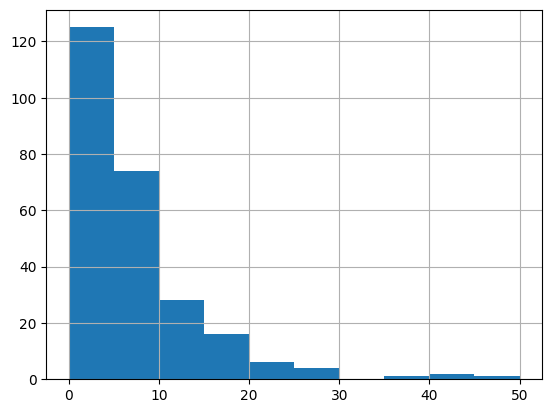

In [54]:
# Code here
air_quality['aqi'].hist()

### Calculate the standard error

Calculate the standard error of the mean AQI using the initial sample of 50. The **standard error** of a statistic measures the sample-to-sample variability of the sample statistic. It provides a numerical measure of sampling variability and answers the question: How far is a statistic based on one particular sample from the actual value of the statistic?

In [55]:
# Code Here
aqi_std = air_quality['aqi'].std()

## Step 4: Results and evaluation

###  Visualize the relationship between the sampling and normal distributions

Visualize the relationship between your sampling distribution of 10,000 estimates and the normal distribution.

1. Plot a histogram of the 10,000 sample means 
2. Add a vertical line indicating the mean of the first single sample of 50
3. Add another vertical line indicating the mean of the means of the 10,000 samples 
4. Add a third vertical line indicating the mean of the actual population

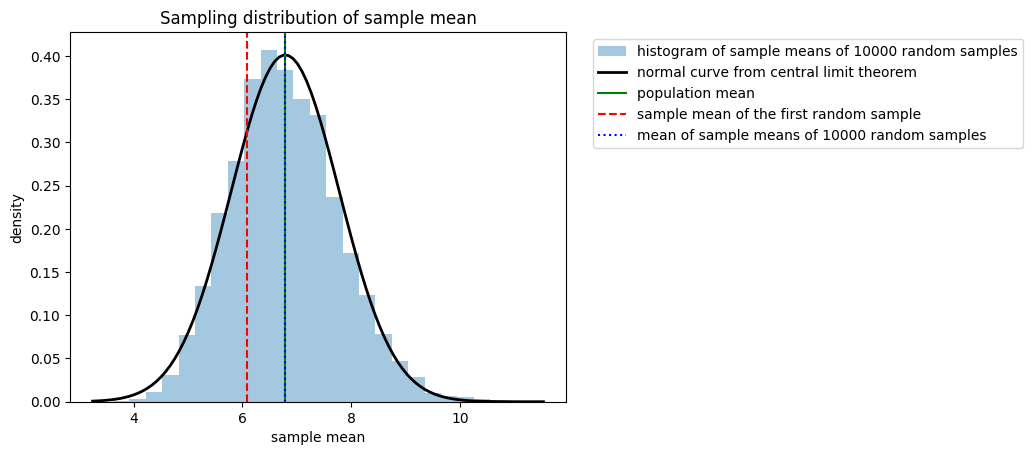

In [56]:
# Code Here
plt.hist(estimate_df['estimate'], bins=25, density=True, alpha=0.4, label = "histogram of sample means of 10000 random samples")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100) # generate a grid of 100 values from xmin to xmax.
p = stats.norm.pdf(x, mean_sample_means, stats.tstd(estimate_df['estimate']))
plt.plot(x, p,'k', linewidth=2, label = 'normal curve from central limit theorem')
plt.axvline(x=population_mean, color='g', linestyle = 'solid', label = 'population mean')
plt.axvline(x = sample_mean, color='r', linestyle = '--', label = 'sample mean of the first random sample')
plt.axvline(x=mean_sample_means, color='b', linestyle = ':', label = 'mean of sample means of 10000 random samples')
plt.title("Sampling distribution of sample mean")
plt.xlabel('sample mean')
plt.ylabel('density')
plt.legend(bbox_to_anchor=(1.04,1))
plt.show()

**Question:** What insights did you gain from the preceding sampling distribution?

A: The sampling distribution confirms the Central Limit Theorem (CLT), showing a nearly normal shape despite the original data distribution. The mean of sample means aligns closely with the population mean, reinforcing that repeated random sampling leads to a reliable estimate. The histogram matches the normal curve, indicating that as sample size increases, the distribution of sample means becomes approximately normal.

# Considerations

**What are some key takeaways that you learned from this project?**

A:This project reinforced the importance of statistical sampling and the Central Limit Theorem (CLT) in data analysis. It demonstrated how random sampling with replacement allows for unbiased estimates of population parameters and how increasing sample size leads to a normal distribution of sample means, regardless of the original data distribution. Additionally, the project highlighted the role of outliers in affecting analysis and the necessity of using Z-scores for outlier detection. Understanding these concepts is essential for making data-driven decisions and ensuring accurate statistical inference.

**What findings would you share with others?**

A: The results confirmed that sampling distributions follow a normal pattern as predicted by CLT, reinforcing the reliability of using sample means to estimate population means. Additionally, identifying outliers in air quality data can provide insights into localized pollution events that require further investigation. Proper data preprocessing, such as handling missing values and checking for duplicates, is crucial for robust statistical analysis.

**What would you convey to external readers?**

A: This study demonstrates how statistical methods can improve data analysis and decision-making, especially in fields like environmental monitoring. By applying sampling techniques and probability distributions, we can make meaningful predictions about air quality trends. The importance of detecting outliers also highlights the need for careful data validation when interpreting results. Understanding these statistical principles allows for more accurate, reliable, and actionable insights.